In [14]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
filename = "data/preprocessed_data1.xlsx"  # removed an outlier row which had value 2861 for k

df = pd.read_excel(filename)
df.columns = df.columns.astype(str)
print(df.head())
for i, col in enumerate(df.columns):
    print(i, col)
spectral_data = df.iloc[:, 1:434]
output_variable = df.iloc[:, 438:439]

   NaN  349.866666666667    354.95     359.3    365.15     369.5   375.325  \
0    1          0.176017  0.299384  0.198790  0.188402  0.222219  0.176474   
1    2          0.351445  0.215237  0.309772  0.252583  0.224695  0.268031   
2    3          0.356503  0.466425  0.423282  0.364149  0.415068  0.376971   
3    4          0.265057  0.203846  0.234168  0.224374  0.198412  0.220841   
4    5          0.205652  0.310290  0.217143  0.205296  0.239884  0.179048   

      379.7   384.075     389.9  ...    2500.3    2504.5  2507.26666666667  \
0  0.193511  0.210975  0.191199  ...  0.853414  0.855469          0.852957   
1  0.247237  0.240092  0.270704  ...  0.896109  0.898336          0.899570   
2  0.377933  0.402530  0.391345  ...  0.905588  0.908209          0.904015   
3  0.214826  0.203175  0.225581  ...  0.873882  0.871049          0.871974   
4  0.200302  0.224692  0.196446  ...  0.860581  0.859435          0.857700   

   EC_mmhos.cm  nitrateN_mg.kg  OM_%  P.olsen_mg.kg  K_mg.kg  

In [16]:
spectral_data.head()
output_variable.head()

,K_mg.kg
0,272
1,335
2,123
3,680
4,1173


In [17]:
print(spectral_data.shape)
print(output_variable.shape)

(41, 432)
(41, 1)


In [18]:
output_variable.describe()

,K_mg.kg
count,41.000000
mean,604.756098
std,490.124055
min,90.000000
25%,278.000000
50%,454.000000
75%,789.000000
max,2861.000000


Text(0.5, 1.0, 'Output K Distribution')

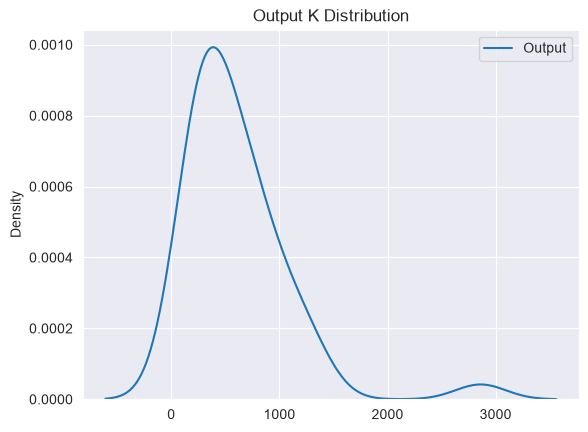

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(output_variable, label='Output')
plt.legend()
plt.title("Output K Distribution")

In [20]:
# skip, no need to apply filter
# from scipy.signal import savgol_filter
#
# X = savgol_filter(spectral_data.values, window_length=11, polyorder=2, deriv=1, axis=1)
y = output_variable.values.ravel()

In [21]:
# skip
# y_log = np.log1p(output_variable.values.ravel())
# sns.kdeplot(y_log)

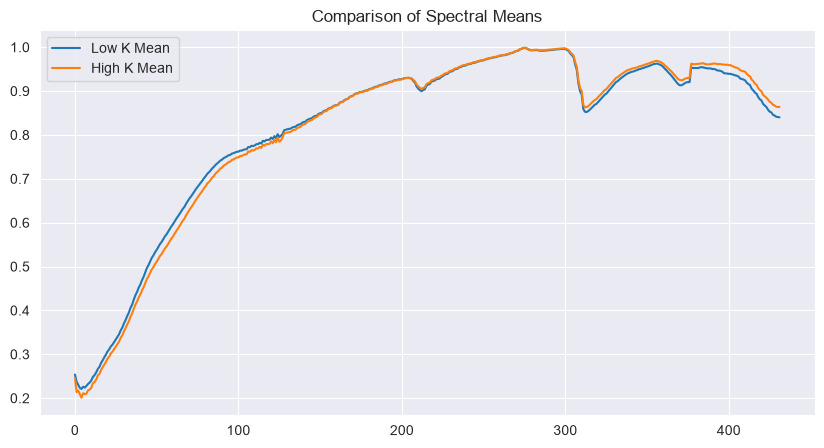

In [22]:
X_train_arr = np.array(spectral_data)

median_val = np.median(y)
low_n = X_train_arr[y <= median_val]
high_n = X_train_arr[y > median_val]

plt.figure(figsize=(10, 5))
plt.plot(np.mean(low_n, axis=0), label='Low K Mean')
plt.plot(np.mean(high_n, axis=0), label='High K Mean')
plt.legend()
plt.title("Comparison of Spectral Means")
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pca', PCA(n_components=10)),
#     ('regressor', Ridge(alpha=1.0))
# ])

# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('feat_select', SelectKBest(score_func=f_regression, k=50)),
#     ('rf', RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42))
# ])

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pls', PLSRegression(n_components=10))
])



from sklearn.base import BaseEstimator, TransformerMixin

# Standard Normal Variate
class SNV(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        return self
    def transform(self, X):
        X_arr = np.array(X)
        return (X_arr - np.mean(X_arr, axis=1, keepdims=True)) / np.std(X_arr, axis=1, keepdims=True)

#
# pipeline = Pipeline([
#     ('snv', SNV()),
#     ('pls', PLSRegression(n_components=10))
# ])

In [24]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

cv = LeaveOneOut()
y_pred = cross_val_predict(pipeline, spectral_data, y, cv=cv)

In [25]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"LOOCV R2 Score: {r2:.4f}")
print(f"LOOCV RMSE: {rmse:.4f}")

LOOCV R2 Score: -0.9357
LOOCV RMSE: 673.5435


In [26]:
#Train Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(spectral_data, y, test_size=0.2, random_state=42)

In [28]:
X_train

,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,400.1,...,2464.26666666667,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,2507.26666666667
6,0.205728,0.262669,0.183015,0.189440,0.204348,0.191499,0.198149,0.207402,0.199190,0.214732,...,0.924864,0.922571,0.919133,0.912979,0.914608,0.908093,0.903237,0.898350,0.897294,0.901819
26,0.285444,0.219818,0.225693,0.217842,0.197544,0.214612,0.215419,0.208208,0.220069,0.226723,...,0.875561,0.872703,0.858225,0.858670,0.855069,0.848461,0.852433,0.846345,0.838141,0.841333
12,0.210071,0.183831,0.183261,0.173681,0.174712,0.182757,0.177715,0.181902,0.186396,0.185256,...,0.856796,0.850717,0.845865,0.837623,0.836717,0.835255,0.828766,0.827948,0.828854,0.822541
17,0.246877,0.211312,0.200853,0.206528,0.183305,0.200159,0.194880,0.189278,0.197631,0.202265,...,0.840851,0.834110,0.839496,0.832028,0.831103,0.826410,0.821057,0.825881,0.827963,0.823370
9,0.271390,0.237230,0.226216,0.225976,0.211796,0.220230,0.225072,0.218740,0.229036,0.234170,...,0.897946,0.896350,0.894115,0.890284,0.891419,0.881061,0.878224,0.879571,0.882090,0.878259
15,0.235588,0.205330,0.252762,0.213328,0.206740,0.236767,0.214160,0.221927,0.240118,0.224862,...,0.932674,0.924815,0.927958,0.922103,0.919514,0.914644,0.913165,0.914428,0.914428,0.911994
32,0.171942,0.154895,0.167036,0.150294,0.157605,0.160679,0.153845,0.162855,0.161939,0.162340,...,0.871106,0.865404,0.859601,0.849496,0.850209,0.845525,0.845347,0.839009,0.842216,0.838271
16,0.278024,0.240642,0.242954,0.240277,0.219859,0.235702,0.231906,0.232636,0.240496,0.244415,...,0.916200,0.911625,0.913020,0.911625,0.907699,0.906206,0.897639,0.905103,0.900949,0.901176
35,0.223273,0.207269,0.203126,0.197809,0.198200,0.199925,0.201401,0.205616,0.207856,0.212213,...,0.858928,0.855466,0.845650,0.839439,0.836925,0.830358,0.824264,0.827204,0.826446,0.824430
34,0.153894,0.166490,0.149428,0.144374,0.150740,0.146823,0.147018,0.151602,0.150270,0.156206,...,0.862900,0.857154,0.849501,0.844042,0.843050,0.836598,0.834378,0.831087,0.833333,0.831322


In [29]:
pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [30]:
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=10)),
    ('regressor', Ridge(alpha=1.0))
])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('regressor', PLSRegression(n_components=2))
# ])

In [31]:
print(pipeline)

Pipeline(steps=[('scaler', MinMaxScaler()), ('pca', PCA(n_components=10)),
                ('regressor', Ridge())])


In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'pca__n_components': [5, 10, 15, 20, 25]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best R2: {grid.best_score_}")
print(f"Best parameters: {grid.best_params_}")

Best R2: 0.12939474433559855
Best parameters: {'pca__n_components': 5}


In [33]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {rmse:.4f}")

R2 Score: -0.4021779385692519
RMSE: 673.5435


Feature Selection using lasso

In [34]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor


selector = SelectFromModel(estimator=Lasso(alpha=0.4)).fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

In [35]:
X_train_selected

array([[0.26266854, 0.20434802, 0.19814949, 0.45120351, 0.47113383,
        0.89792779, 0.89525835, 0.97900642, 0.91913251],
       [0.21981847, 0.19754427, 0.21541931, 0.49880276, 0.52380555,
        0.91535806, 0.91079185, 0.96580911, 0.85822475],
       [0.18383094, 0.17471174, 0.17771494, 0.38947345, 0.4072296 ,
        0.9083695 , 0.90433601, 0.95172958, 0.84586494],
       [0.21131159, 0.18330524, 0.19487955, 0.44584614, 0.46688807,
        0.88044017, 0.87632596, 0.93442054, 0.83949638],
       [0.23722997, 0.21179632, 0.22507183, 0.52466213, 0.54887198,
        0.92055975, 0.9164627 , 0.96403107, 0.89411514],
       [0.20533031, 0.20674033, 0.21416023, 0.4895058 , 0.50996255,
        0.9140123 , 0.91096112, 0.97586797, 0.92795833],
       [0.15489462, 0.15760538, 0.15384469, 0.28602245, 0.29512828,
        0.88668296, 0.8849267 , 0.96235492, 0.8596009 ],
       [0.24064249, 0.21985885, 0.23190557, 0.49576539, 0.51545388,
        0.91321489, 0.91000243, 0.97298613, 0.9130202 ],


In [36]:
pls = PLSRegression(n_components=7)
pls.fit(X_train_selected, y_train)

# 5. Prediction & Evaluation
y_pred = pls.predict(X_test_selected)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: -0.06598883429440727
RMSE: 867.7695174183351


In [37]:
#Feature Importance from Random Forest

In [38]:
# 2. Using Random Forest importance
rf = RandomForestRegressor().fit(X_train, y_train)
selector_rf = SelectFromModel(rf, threshold='median').fit(X_train, y_train)
X_train_selected_rf = selector_rf.transform(X_train)
X_test_selected_rf = selector_rf.transform(X_test)

pls = PLSRegression(n_components=6)
pls.fit(X_train_selected_rf, y_train)

y_pred = pls.predict(X_test_selected_rf)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: -0.40455144156839795
RMSE: 996.086117695179


In [39]:
X_train_selected_rf

array([[0.20572799, 0.26266854, 0.18301511, ..., 0.90809278, 0.90323651,
        0.89729436],
       [0.28544381, 0.21981847, 0.22569328, ..., 0.84846122, 0.85243346,
        0.83814085],
       [0.21007059, 0.18383094, 0.18326099, ..., 0.83525509, 0.82876642,
        0.82885411],
       ...,
       [0.19439401, 0.19884249, 0.1907626 , ..., 0.83183538, 0.82423967,
        0.82520805],
       [0.26754091, 0.21133154, 0.22282   , ..., 0.87648509, 0.87936188,
        0.87274901],
       [0.16036785, 0.16611237, 0.14897959, ..., 0.80749139, 0.80735702,
        0.80715545]], shape=(32, 216))

In [40]:
mask = selector_rf.get_support()

selected_columns = X_train.columns[mask]

# 3. View the results
print(f"Number of features selected: {len(selected_columns)}")
print("Selected columns (wavelengths):")
print(selected_columns)

Number of features selected: 216
Selected columns (wavelengths):
Index(['354.95', '359.3', '365.15', '369.5', '379.7', '384.075', '389.9',
       '394.275', '400.1', '414.65',
       ...
       '2444.9', '2452.13333333333', '2464.26666666667', '2467.13333333333',
       '2474.96666666667', '2479.2', '2482.06666666667', '2489.8', '2494',
       '2504.5'],
      dtype='str', length=216)


In [41]:
#RF with Grid Search CV

In [42]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Define a pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    # ('pca', PCA(n_components=10)),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameters to tune
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# Use 5-fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_}")

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best CV RMSE: 0.06155277334733049


In [43]:
best_rf = grid.best_estimator_

In [44]:
y_test_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Test R²: -0.08326872026474508
Test MSE: 765230.5995555556
